In [12]:
#This is a supervised machine learning regression problem.

In [2]:
# Step 1: Import required libraries
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

In [3]:
# Step 2: Load dataset and convert to DataFrame
housing_data = fetch_california_housing()
data = pd.DataFrame(housing_data.data, columns=housing_data.feature_names)
data['TargetPrice'] = housing_data.target  # Renamed column
data.head()


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,TargetPrice
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


In [4]:
# Step 3: Basic data check
print(data.info())
print(data.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   MedInc       20640 non-null  float64
 1   HouseAge     20640 non-null  float64
 2   AveRooms     20640 non-null  float64
 3   AveBedrms    20640 non-null  float64
 4   Population   20640 non-null  float64
 5   AveOccup     20640 non-null  float64
 6   Latitude     20640 non-null  float64
 7   Longitude    20640 non-null  float64
 8   TargetPrice  20640 non-null  float64
dtypes: float64(9)
memory usage: 1.4 MB
None
MedInc         0
HouseAge       0
AveRooms       0
AveBedrms      0
Population     0
AveOccup       0
Latitude       0
Longitude      0
TargetPrice    0
dtype: int64


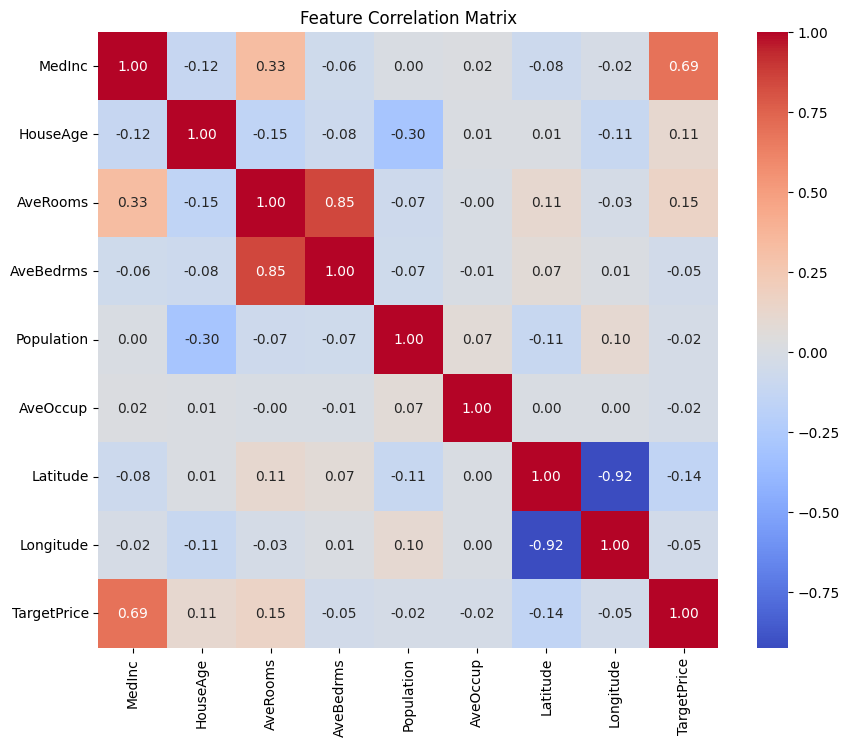

In [5]:
# Step 4: Correlation heatmap to understand relationships
plt.figure(figsize=(10, 8))
sns.heatmap(data.corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Feature Correlation Matrix")
plt.show()


In [6]:
# Step 5: Prepare features and target
features = data.drop('TargetPrice', axis=1)
target = data['TargetPrice']

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(features, target, test_size=0.2, random_state=100)


In [7]:
# Step 6: Initialize and train the regression model
regressor = LinearRegression()
regressor.fit(X_train, y_train)


LinearRegression()

In [8]:
# Step 7: Predict house prices on test set
predicted_prices = regressor.predict(X_test)

# Step 8: Evaluate model performance
mse_score = mean_squared_error(y_test, predicted_prices)
r2 = r2_score(y_test, predicted_prices)

print(f"📉 Mean Squared Error: {mse_score}")
print(f"✅ R-squared Score: {r2}")


📉 Mean Squared Error: 0.5088933351158946
✅ R-squared Score: 0.622313810729529


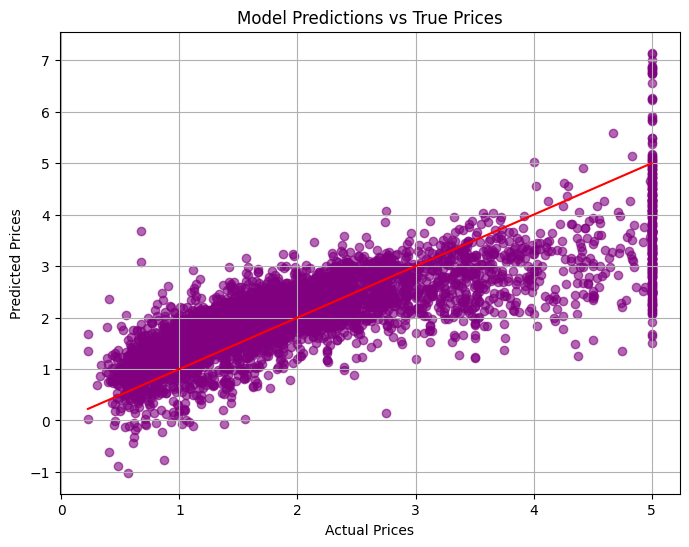

In [9]:
# Step 9: Plot actual vs predicted prices
plt.figure(figsize=(8,6))
plt.scatter(y_test, predicted_prices, color='purple', alpha=0.6)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='red')
plt.xlabel("Actual Prices")
plt.ylabel("Predicted Prices")
plt.title("Model Predictions vs True Prices")
plt.grid(True)
plt.show()

In [10]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor()
rf.fit(X_train, y_train)

rf_preds = rf.predict(X_test)

rf_r2 = r2_score(y_test, rf_preds)
print("Random Forest R2:", rf_r2)

Random Forest R2: 0.8208527937200615


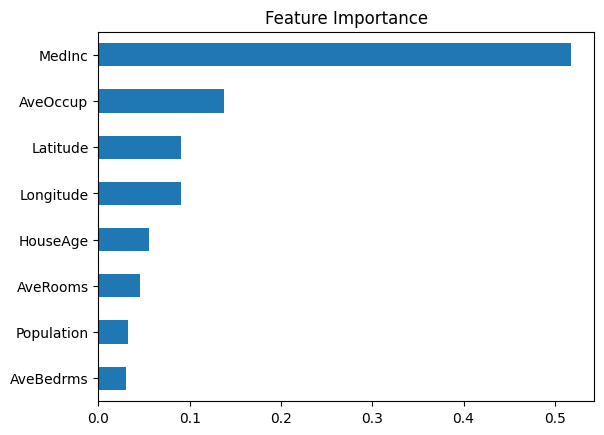

In [11]:
import pandas as pd

importance = pd.Series(rf.feature_importances_, index=X_train.columns)
importance.sort_values().plot(kind='barh')
plt.title("Feature Importance")
plt.show()

In [ ]:
#Built a regression model to predict California housing prices using features like income, location, and housing characteristics.
# I started with Linear Regression, achieving an R² of 0.62, but it underperformed due to non-linear relationships.
# I then applied Random Forest, which improved performance to an R² of 0.82. Feature importance analysis showed median income and location were the most influential factors.